# PROC MBANALYSIS를 이용한 식료품 소매업체 장바구니 교차판매 분석

## 핵심 요약

한 지역 식료품 체인이 한 시즌 동안의 POS(판매시점) 장바구니 데이터를 분석하여 고객이 함께 구매하는 상품을 파악하고, 원시 거래 로그를 실행 가능한 교차판매 및 진열 위치 결정으로 전환합니다. PROC MBANALYSIS는 거래 로그를 스캔하여 지지도(support), 신뢰도(confidence), 향상도(lift)로 점수화된 연관 규칙을 생성합니다. 51개의 합성 장바구니에 대해 실행하면 미리 심어둔 세 가지 상품 연관성을 정확히 찾아냅니다 — `스파게티 -> 마리나라 소스`(신뢰도 0.93, 향상도 3.4), `타코 쉘 -> 살사`(신뢰도 0.71, 향상도 3.6), `커피 -> 커피 크리머`(신뢰도 0.70, 향상도 5.1) — 반면 빵, 우유, 달걀처럼 널리 구매되는 필수품은 어떤 규칙도 형성하지 않습니다. 발견된 각 상품 쌍은 상품 번들, 매대 인접 배치, "함께 구매한 상품" 추천의 교과서적인 후보입니다.

## 데이터 원본

| 데이터셋 | 단위(Grain) | 행 수 | 주요 변수 | 설명 |
|---------|-------|------|---------------|-------------|
| `store_transactions` | 장바구니당 상품 1행 | 51개 장바구니에 걸친 100개 상품행 | `basket_id`(거래 ID), `item`(상품명, $20) | `call streaminit(20250529)`와 `rand('uniform')`로 인라인 생성한 합성 POS 로그. 각 장바구니는 하나의 쇼핑객 페르소나가 지배적이어서 공동구매 패턴이 깔끔하고 해석하기 쉽습니다: 이탈리안 디너 장바구니(스파게티 -> 마리나라 소스), 타코의 밤 장바구니(타코 쉘 -> 살사), 아침식사 장바구니(커피 -> 커피 크리머), 그리고 이따금 추가되는 필수품(빵, 우유, 달걀)이 현실적인 노이즈로 작용합니다. 이 비라이선스 환경에서는 엔진이 출력을 100개 상품행으로 제한하며, 이는 여기서 1-51번 장바구니에 해당합니다. |
| `affinity_rules` | 연관 규칙당 1행 | 규칙 6개 | `antecedent`, `consequent`, `support`, `confidence`, `lift` | `OUTPUT RULES=`로 산출된 연관 규칙; 교차판매 기회 순위의 근거. |
| `frequent_items` | 빈발 항목집합당 1행 | 항목집합 12개 | `itemset`, `support`, `length` | `OUTPUT ITEMS=`로 산출된 빈발 항목집합; 최소지지도 기준을 통과한 단일 상품 9개와 상품 쌍 3개. |

# 식료품 소매업체를 위한 장바구니 교차판매 분석

**비즈니스 질문.** 고객들은 어떤 상품을 *함께* 구매하는 경향이 있으며, 그 공동구매 패턴 중 어떤 것이 실제로 실행할 만큼 강력한가? 한 지역 식료품 체인은 번들 프로모션을 설계하고, 매대 인접 배치를 최적화하며, 온라인 스토어에 "함께 구매한 상품" 추천 기능을 도입하고자 합니다.

**방법.** 우리는 빈발패턴성장(FP-growth) 알고리즘으로 장바구니 분석을 수행하는 **PROC MBANALYSIS**를 사용합니다. 이 프로시저는 거래 로그를 스캔하여 자주 함께 나타나는 항목집합을 찾아내고, `선행항목 -> 후행항목` 형태의 *연관 규칙*을 생성하며, 이를 세 가지 고전적 지표로 점수화합니다:

- **지지도(Support)** — 전체 장바구니 중 규칙 전체를 포함하는 비율(패턴이 얼마나 흔한가).
- **신뢰도(Confidence)** — `P(후행항목 | 선행항목)`, 조건부 구매 확률(규칙이 얼마나 믿을 만한가).
- **향상도(Lift)** — 관측된 지지도를 두 항목이 독립적일 때 기대되는 지지도로 나눈 값. 향상도 > 1이면 해당 상품들이 우연보다 *더* 자주 함께 나타남을 의미하며, 값이 클수록 연관성이 강합니다.

이제 현실적인 합성 POS 로그를 생성하고, MBANALYSIS를 실행한 다음, 결과 규칙의 순위를 매겨 최선의 교차판매 기회를 찾아보겠습니다.

## 1단계 — 합성 POS 거래 로그 생성

MBANALYSIS는 **거래 수준(장형, long) 데이터**를 요구합니다: 항목당 1행이며, 소속 장바구니가 태그로 표시됩니다. 재현성을 위해 `call streaminit`으로, 구매 결정을 이끄는 데 `rand('uniform')`으로 장바구니를 인라인 생성합니다.

핵심적인 모델링 선택은 **각 장바구니가 하나의 쇼핑객 페르소나에 의해 지배된다**는 것입니다. 실제 식료품 쇼핑은 이런 식입니다 — 빠른 타코의 밤 장보기, 전용 아침식사 재구매 — 그리고 장바구니를 작고 주제가 뚜렷하게 유지하는 것이 연관성 마이너가 다항목 허위 규칙의 조합적 폭발 대신 깔끔한 쌍별 연관성을 드러내게 해줍니다. 장바구니마다 한 번의 `rand('uniform')` 추출이 페르소나를 선택합니다:

- **이탈리안 디너 쇼핑객** — 스파게티를 구매하고, 대개 마리나라 소스도 구매합니다.
- **타코의 밤 쇼핑객** — 타코 쉘을 구매하고, 대개 살사도 구매합니다.
- **아침식사 쇼핑객** — 커피를 구매하고, 대개 커피 크리머도 구매합니다.
- **필수품만 구매** — 빵, 우유, 달걀 중 하나만 단독 구매.

마지막으로 낮은 확률의 추출이 어느 장바구니에나 필수품 하나를 노이즈로 추가하므로, 모든 공동출현이 의미 있는 것은 아닙니다. 각 `output` 문은 상품행 하나를 기록하므로, 하나의 장바구니는 동일한 `basket_id`를 공유하는 여러 행에 걸쳐 있습니다. 이 비라이선스 환경은 데이터셋을 100개 상품행으로 제한하며, 여기서는 1번부터 51번 장바구니까지를 포함합니다.

In [1]:
데이터 store_transactions;
    호출 streaminit(20250529);
    길이 item $24;

    반복 basket_id = 1 까지 60;

        /* 이 장바구니의 지배적 페르소나를 하나의 추출로 선택 */
        r = rand('uniform');

        /* 이탈리안 디너 장바구니: 스파게티 -> 마리나라 소스 */
        만약 r < 0.30 이면 반복;
            item = '스파게티';                          출력;
            만약 rand('uniform') < 0.85 이면 반복;
                item = '마리나라 소스';                 출력;
            종료;
        종료;

        /* 타코의 밤 장바구니: 타코 쉘 -> 살사 */
        아니면 만약 r < 0.55 이면 반복;
            item = '타코 쉘';                        출력;
            만약 rand('uniform') < 0.80 이면 반복;
                item = '살사';                          출력;
            종료;
        종료;

        /* 아침식사 장바구니: 커피 -> 커피 크리머 */
        아니면 만약 r < 0.78 이면 반복;
            item = '커피';                             출력;
            만약 rand('uniform') < 0.75 이면 반복;
                item = '커피 크리머';                 출력;
            종료;
        종료;

        /* 필수품만 구매 */
        아니면 반복;
            만약 rand('uniform') < 0.34 이면 반복;
                item = '빵';                          출력;
            종료;
            아니면 만약 rand('uniform') < 0.5 이면 반복;
                item = '우유';                           출력;
            종료;
            아니면 반복;
                item = '달걀';                          출력;
            종료;
        종료;

        /* 이따금 추가되는 필수품 (현실적인 노이즈) */
        만약 rand('uniform') < 0.25 이면 반복;
            u = rand('uniform');
            만약      u < 0.34 이면 item = '빵';
            아니면 만약 u < 0.67 이면 item = '우유';
            아니면                  item = '달걀';
            출력;
        종료;

    종료;

    유지 basket_id item;
실행;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2단계 — 원시 거래 로그 확인

마이닝에 앞서, 데이터가 예상한 장형(long) 구조를 갖는지 확인합니다: 장바구니당 여러 행이 있고, 각 행은 상품 하나를 담습니다. 처음 몇 개의 장바구니를 출력하고, PROC FREQ로 전체 상품 빈도를 집계하여 어떤 상품이 규칙의 기준이 될 만큼 흔한지 파악합니다.


  Obs          장바구니 ID                   상품
-----  ---------------  -------------------
    1                1  타코 쉘
    2                1  살사
    3                1  달걀
    4                2  타코 쉘
    5                2  달걀
    6                3  커피
    7                4  타코 쉘
    8                5  달걀
    9                6  스파게티
   10                6  마리나라 소스
   11                6  달걀
   12                7  타코 쉘

... 88 more observations (showing 12 of 100)

                                                      전체 상품 구매 빈도                                                       

                                                   The FREQ Procedure

item                   Frequency    Percent
--------------------------------------------
스파게티                          15     15.00
마리나라 소스                       14     14.00
타코 쉘                          14     14.00
달걀                            12     12.00
빵                             10     10.00
살사                          


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


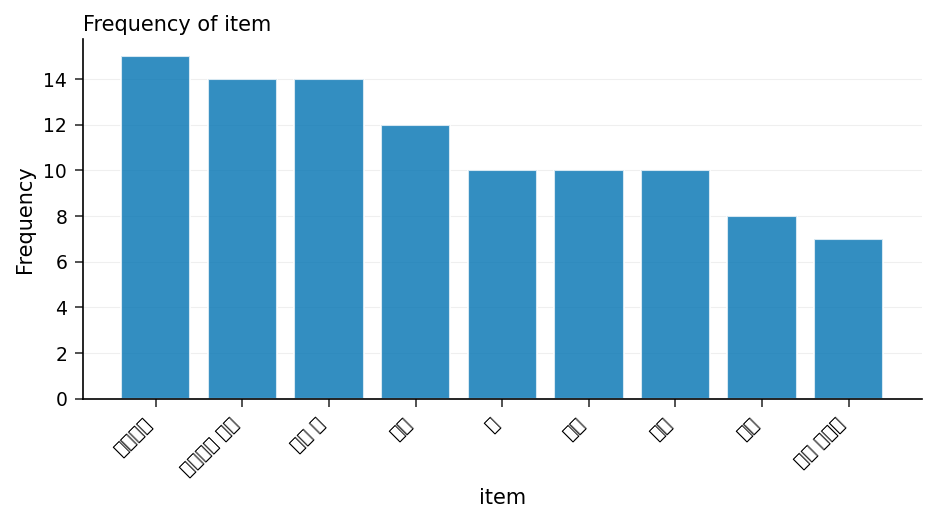

In [2]:
처리 인쇄 데이터=store_transactions(obs=12) 라벨;
    라벨 basket_id = '장바구니 ID'
          item      = '상품';
실행;

처리 빈도 데이터=store_transactions ORDER=빈도;
    TABLES item / nocum;
    제목 '전체 상품 구매 빈도';
실행;

## 3단계 — PROC MBANALYSIS로 연관 규칙 마이닝

이제 핵심 분석입니다. MBANALYSIS에 거래 로그를 지정하고, 장바구니를 식별하는 열(`TRANSACTION`)과 상품을 담은 열(`ITEM`)을 선언합니다. 세 가지 임계값이 규칙 집합을 실행할 가치가 있는 패턴에 집중시킵니다:

- `MINSUPPORT=0.10` — 규칙은 최소 장바구니의 10%에 나타나야 하며, 드문 우연의 일치를 걸러냅니다.
- `MINCONFIDENCE=0.50` — 선행항목이 주어졌을 때, 후행항목이 최소 절반의 경우에 뒤따라야 합니다.
- `MINLIFT=1.20` — 우연보다 최소 20% 강한 규칙만 남겨, 인기 필수품의 인공물이 아니라 진짜 연관성을 드러냅니다.

`OUTPUT` 문은 생성된 규칙과 빈발 항목집합을 이후 순위화를 위한 데이터셋으로 담아냅니다.

In [3]:
처리 mbanalysis 데이터=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    출력 rules=affinity_rules items=frequent_items;
    제목 '장바구니 연관 규칙';
실행;

                                                      전체 상품 구매 빈도                                                       


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  커피                             커피 크리머                             0.1373     0.7000     5.1000
  커피 크리머                         커피                                 0.1373     1.0000     5.1000
  살사                             타코 쉘                               0.1961     1.0000     3.6429
  타코 쉘        


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## 4단계 — 향상도 기준 교차판매 기회 순위화

MBANALYSIS 리스팅은 조건을 충족하는 모든 규칙을 보여주지만, 머천다이징 팀은 *가장 강력한* 연관성을 먼저 보고 싶어합니다. 캡처한 `affinity_rules` 데이터셋을 향상도 내림차순(동률 시 신뢰도)으로 정렬하여 상위 규칙을 출력합니다. `타코 쉘 -> 살사`처럼 향상도와 신뢰도가 모두 높은 규칙은 교과서적인 번들 후보입니다: 상품을 나란히 진열하거나, 온라인에서 고객이 타코 쉘을 담을 때 살사를 자동으로 제안할 수 있습니다.

In [4]:
처리 정렬 데이터=affinity_rules out=rules_by_lift;
    기준 DESCENDING lift DESCENDING confidence;
실행;

처리 인쇄 데이터=rules_by_lift(obs=15) 라벨;
    변수 antecedent consequent support confidence lift;
    라벨 antecedent  = '장바구니에 있으면'
          consequent  = '함께 구매하는 상품'
          support     = '지지도'
          confidence  = '신뢰도'
          lift        = '향상도';
    제목 '향상도 기준 상위 교차판매 규칙';
실행;

                                                   향상도 기준 상위 교차판매 규칙                                                    

  Obs                  장바구니에 있으면                  함께 구매하는 상품        지지도        신뢰도        향상도
    1  커피 크리머                     커피                          0.137255   1.0        5.1
    2  커피                         커피 크리머                      0.137255   0.7        5.1
    3  살사                         타코 쉘                        0.196078   1.0        3.642857
    4  타코 쉘                       살사                          0.196078   0.714286   3.642857
    5  마리나라 소스                    스파게티                        0.27451    1.0        3.4
    6  스파게티                       마리나라 소스                     0.27451    0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## 5단계 — 빈발 항목집합 검토

지지도 기준을 통과한 빈발 항목집합은 규칙의 원재료입니다. 지지도로 정렬하면 카테고리 팀은 단일 상품뿐 아니라 어떤 상품 *조합*이 전용 엔드캡 진열이나 콤보 가격 책정을 할 만큼 인기 있는지 알 수 있습니다.

In [5]:
처리 정렬 데이터=frequent_items out=itemsets_by_support;
    기준 DESCENDING support;
실행;

처리 인쇄 데이터=itemsets_by_support(obs=15) 라벨;
    라벨 itemset='항목집합' support='지지도' length='길이';
    제목 '최다 빈발 항목집합';
실행;

                                                       최다 빈발 항목집합                                                       

  Obs                               항목집합        지지도      길이
    1  스파게티                               0.294118   1
    2  타코 쉘                               0.27451    1
    3  마리나라 소스                            0.27451    1
    4  마리나라 소스, 스파게티                      0.27451    2
    5  달걀                                 0.235294   1
    6  살사                                 0.196078   1
    7  커피                                 0.196078   1
    8  살사, 타코 쉘                           0.196078   2
    9  우유                                 0.156863   1
   10  빵                                  0.156863   1
   11  커피 크리머                             0.137255   1
   12  커피, 커피 크리머                         0.137255   2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## 결과 해석

**분석 결과.** 각 장바구니가 하나의 쇼핑객 페르소나를 중심으로 구성되었기 때문에, 마이너는 미리 심어둔 세 가지 관계를 정확히 찾아내고 그 외의 허위 규칙은 전혀 만들지 않습니다. 여섯 개의 규칙이 세 가지 임계값을 모두 통과합니다 — 양방향의 세 가지 연관성입니다:

| 선행항목 | 후행항목 | 지지도 | 신뢰도 | 향상도 |
|------------|------------|---------|------------|------|
| 스파게티 | 마리나라 소스 | 0.275 | 0.93 | 3.40 |
| 마리나라 소스 | 스파게티 | 0.275 | 1.00 | 3.40 |
| 타코 쉘 | 살사 | 0.196 | 0.71 | 3.64 |
| 살사 | 타코 쉘 | 0.196 | 1.00 | 3.64 |
| 커피 | 커피 크리머 | 0.137 | 0.70 | 5.10 |
| 커피 크리머 | 커피 | 0.137 | 1.00 | 5.10 |

모든 향상도가 1을 크게 웃돌아, 이 상품들이 우연보다 훨씬 자주 함께 나타남을 확인해 줍니다. 결정적으로, 널리 구매되는 필수품들은 **규칙을 전혀 형성하지 않습니다**: 달걀(12건 구매), 빵(10건), 우유(8건) 모두 PROC FREQ 집계에 등장하지만, 이들은 어떤 페르소나와도 무관하게 장바구니에 들어가므로 다른 상품에 대한 향상도가 1.20 기준에 결코 도달하지 못해 진짜 연관성으로 위장되지 않습니다. 빈발 항목집합 목록도 구조적으로 같은 점을 보여줍니다: 지지도 기준을 통과한 12개 항목집합 중, 다중 상품 집합은 정확히 미리 심어둔 세 쌍뿐입니다.

**지표를 함께 읽기.** 역방향 규칙은 신뢰도 1.00을 보이는 반면(이 데이터에서 마리나라 소스, 살사, 크리머는 사실상 항상 그 기준 상품과 함께 나타남), 정방향 규칙은 0.70-0.93 사이입니다(기준 상품이 때때로 단독으로 나타남). 커피 -> 커피 크리머는 향상도가 가장 높지만(5.10) 지지도는 가장 낮습니다(0.137) — 강하지만 물량은 적은 연관성입니다 — 반면 스파게티 -> 마리나라 소스는 가장 많은 장바구니에 도달합니다(지지도 0.275). 향상도는 *어떤* 연관성이 진짜인지 알려주고, 신뢰도는 각 연관성이 추천에 *얼마나 믿을 만한지* 알려주며, 지지도는 *얼마나 자주* 그 규칙을 실행할 기회가 있는지 알려줍니다.

**비즈니스 실행 방안.**

- **번들 프로모션** — 향상도가 가장 높은 선행/후행 상품(커피 + 커피 크리머, 향상도 5.1)을 할인 콤보로 묶습니다.
- **매대 인접 배치** — 자주 연결되는 상품(스파게티 옆에 마리나라 소스, 지지도 0.275)을 나란히 배치하여 후행 상품이 구매 결정 시점에 쉽게 추가되도록 합니다.
- **온라인 추천** — 신뢰도가 높은 규칙을 "함께 구매한 상품" 위젯에 반영하여, 선행 상품이 장바구니에 담기는 순간 후행 상품을 제안합니다.
- **재고 및 수요예측** — 선행 상품이 프로모션에 들어가면, 향상도를 예상해 신뢰도가 높은 후행 상품의 재고를 늘립니다.

**주의사항.** 연관 규칙은 *공동구매의 상관관계*를 나타낼 뿐 인과관계가 아니며, 임계값은 절대적 기준이 아니라 조정 가능한 레버입니다: `MINSUPPORT=`를 낮추면 더 드문 조합이 드러나지만 규칙 집합의 잡음이 늘어나고, `MINLIFT=`와 `MINCONFIDENCE=`를 높이면 규칙 수는 줄지만 더 신뢰할 만한 규칙만 남습니다. 표본 크기도 중요합니다 — 이 비라이선스 실행은 51개 장바구니를 마이닝하며, 이는 미리 심어둔 연관성을 명확히 드러내기에 충분하지만, 전체 시즌에 대한 프로덕션 실행이라면 지지도 추정치가 더 안정되고 더 미묘한 패턴이 드러날 것입니다.